# This is a markdown cell - change the cell type to "Text" in Colab

# 🇳🇬 Nigerian Job Market Analysis 2024
### A Data Analysis Portfolio Project

**Author:** Promise kamsy

**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** 250 Nigerian tech job listings  

---

## Objective
Analyze the Nigerian tech job market to uncover:
- Most in-demand skills
- Salary ranges by role
- Top hiring companies
- Location and remote work trends
- Experience level demand

---

In [2]:
from google.colab import files
uploaded = files.upload()

Saving jobs_raw.csv to jobs_raw (1).csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('jobs_raw.csv')

# Basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (250, 8)

First 5 rows:


,title,company,location,salary_ngn,skills,experience,job_type,source
0,Machine Learning Engineer,Jumia,Ibadan,414000,"MLOps, PyTorch",Mid Level,Full Time,Nigerian Job Market 2024
1,Machine Learning Engineer,Paystack,Lagos,858000,"Docker, SQL",Entry Level,Contract,Nigerian Job Market 2024
2,Software Engineer,MTN Nigeria,Kano,458000,"Java, Docker, Python, SQL",Mid Level,Hybrid,Nigerian Job Market 2024
3,Business Analyst,Softcom,Remote,292000,"Excel, Requirements Analysis",Mid Level,Contract,Nigerian Job Market 2024
4,Cloud Engineer,Interswitch,Enugu,644000,"AWS, Terraform",Senior Level,Remote,Nigerian Job Market 2024


/tmp/ipykernel_6635/1182485819.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills, x='Count', y='Skill', palette='viridis')


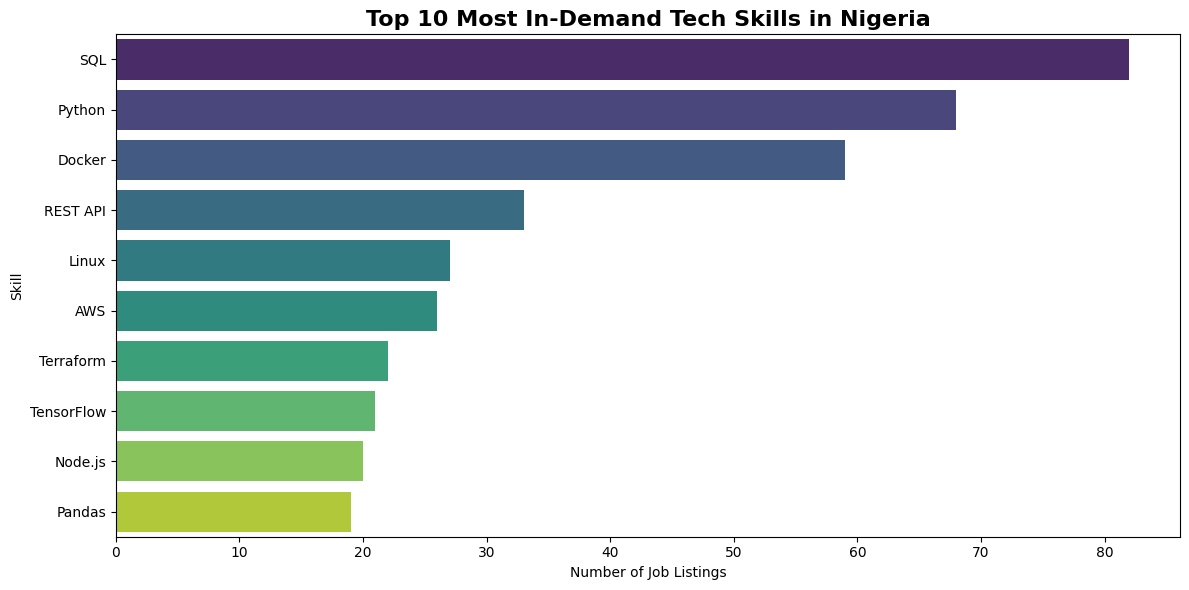

        Skill  Count
0         SQL     82
1      Python     68
2      Docker     59
3    REST API     33
4       Linux     27
5         AWS     26
6   Terraform     22
7  TensorFlow     21
8     Node.js     20
9      Pandas     19


In [4]:
# ---- Analysis 1: Top 10 most in-demand skills ----
from collections import Counter

all_skills = []
for skills in df['skills'].dropna():
    for skill in skills.split(','):
        all_skills.append(skill.strip())

skill_counts = Counter(all_skills)
top_skills = pd.DataFrame(skill_counts.most_common(10), columns=['Skill', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_skills, x='Count', y='Skill', palette='viridis')
plt.title('Top 10 Most In-Demand Tech Skills in Nigeria', fontsize=16, fontweight='bold')
plt.xlabel('Number of Job Listings')
plt.ylabel('Skill')
plt.tight_layout()
plt.savefig('chart1_top_skills.png', dpi=150)
plt.show()

print(top_skills)

/tmp/ipykernel_6635/1265857752.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_salary, x='Average Salary (NGN)', y='Job Title', palette='coolwarm')


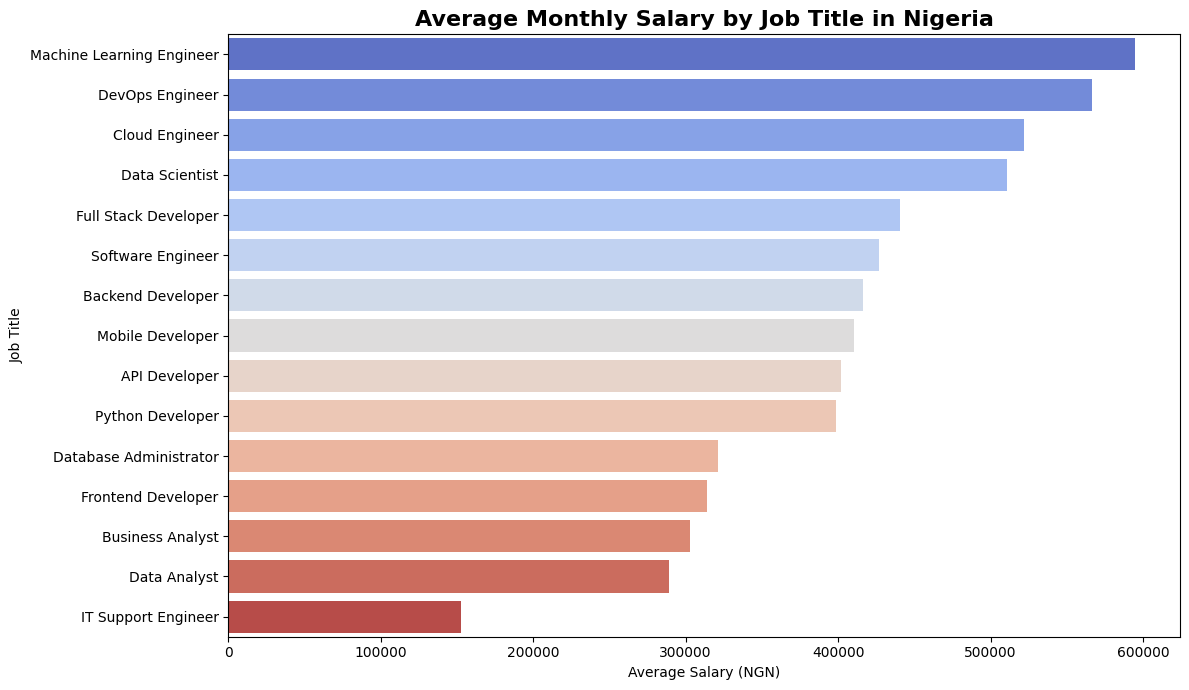

                    Job Title  Average Salary (NGN)
0   Machine Learning Engineer              594500.0
1             DevOps Engineer              566409.0
2              Cloud Engineer              521632.0
3              Data Scientist              510810.0
4        Full Stack Developer              440667.0
5           Software Engineer              426824.0
6           Backend Developer              416562.0
7            Mobile Developer              410500.0
8               API Developer              401944.0
9            Python Developer              398500.0
10     Database Administrator              320917.0
11         Frontend Developer              313917.0
12           Business Analyst              302632.0
13               Data Analyst              289083.0
14        IT Support Engineer              152600.0


In [5]:
# ---- Analysis 2: Average salary by job title ----
avg_salary = df.groupby('title')['salary_ngn'].mean().sort_values(ascending=False).reset_index()
avg_salary['salary_ngn'] = avg_salary['salary_ngn'].round(0)
avg_salary.columns = ['Job Title', 'Average Salary (NGN)']

plt.figure(figsize=(12, 7))
sns.barplot(data=avg_salary, x='Average Salary (NGN)', y='Job Title', palette='coolwarm')
plt.title('Average Monthly Salary by Job Title in Nigeria', fontsize=16, fontweight='bold')
plt.xlabel('Average Salary (NGN)')
plt.ylabel('Job Title')
plt.tight_layout()
plt.savefig('chart2_salary_by_title.png', dpi=150)
plt.show()

print(avg_salary)

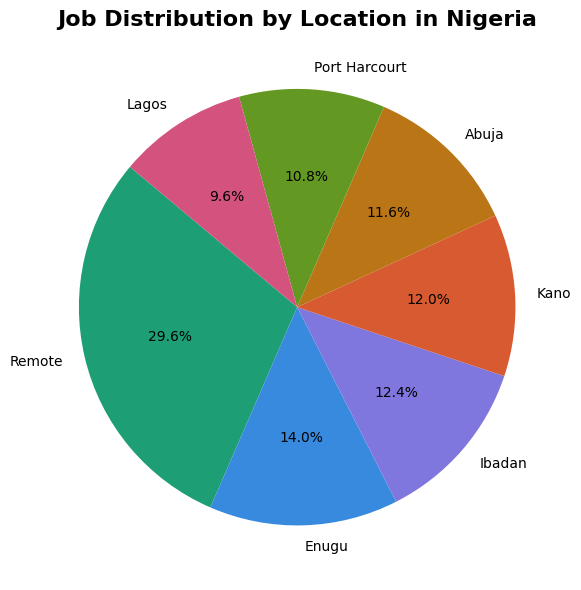

        Location  Job Count
0         Remote         74
1          Enugu         35
2         Ibadan         31
3           Kano         30
4          Abuja         29
5  Port Harcourt         27
6          Lagos         24


In [6]:
# ---- Analysis 3: Job opportunities by city ----
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['Location', 'Job Count']

plt.figure(figsize=(10, 6))
colors = ['#1D9E75', '#378ADD', '#7F77DD', '#D85A30', '#BA7517', '#639922', '#D4537E', '#888780']
plt.pie(location_counts['Job Count'], labels=location_counts['Location'],
        autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Job Distribution by Location in Nigeria', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_jobs_by_location.png', dpi=150)
plt.show()

print(location_counts)

/tmp/ipykernel_6635/669857966.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=job_type_counts, x='Job Type', y='Count', palette='Set2')


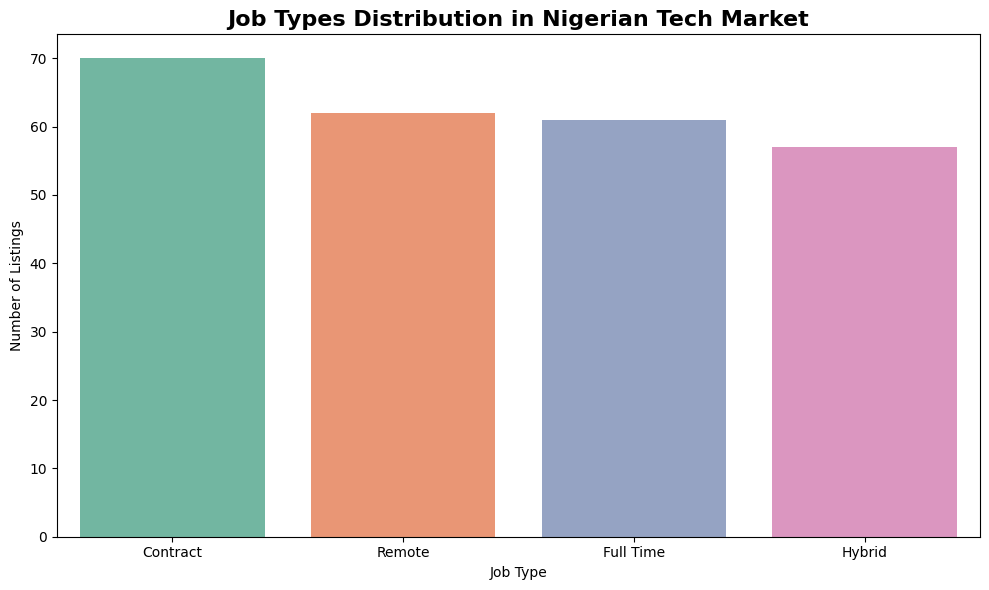

    Job Type  Count
0   Contract     70
1     Remote     62
2  Full Time     61
3     Hybrid     57


In [7]:
# ---- Analysis 4: Job types distribution ----
job_type_counts = df['job_type'].value_counts().reset_index()
job_type_counts.columns = ['Job Type', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=job_type_counts, x='Job Type', y='Count', palette='Set2')
plt.title('Job Types Distribution in Nigerian Tech Market', fontsize=16, fontweight='bold')
plt.xlabel('Job Type')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.savefig('chart4_job_types.png', dpi=150)
plt.show()

print(job_type_counts)

/tmp/ipykernel_6635/3407898076.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_companies, x='Job Listings', y='Company', palette='Blues_r')


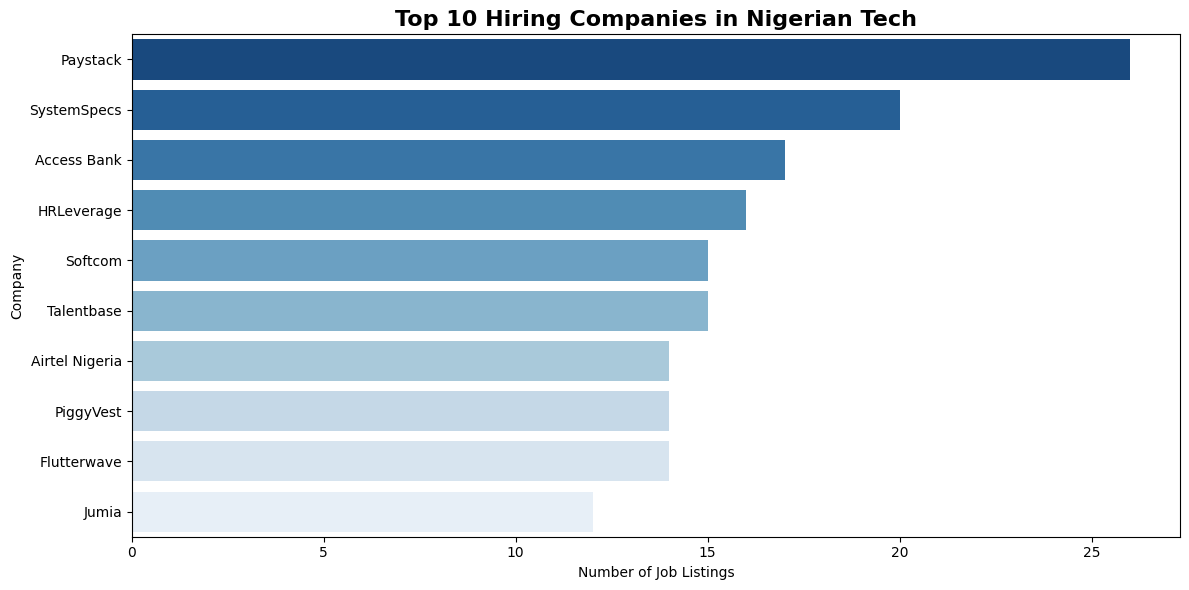

          Company  Job Listings
0        Paystack            26
1     SystemSpecs            20
2     Access Bank            17
3      HRLeverage            16
4         Softcom            15
5      Talentbase            15
6  Airtel Nigeria            14
7       PiggyVest            14
8     Flutterwave            14
9           Jumia            12


In [8]:
# ---- Analysis 5: Top hiring companies ----
top_companies = df['company'].value_counts().head(10).reset_index()
top_companies.columns = ['Company', 'Job Listings']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_companies, x='Job Listings', y='Company', palette='Blues_r')
plt.title('Top 10 Hiring Companies in Nigerian Tech', fontsize=16, fontweight='bold')
plt.xlabel('Number of Job Listings')
plt.ylabel('Company')
plt.tight_layout()
plt.savefig('chart5_top_companies.png', dpi=150)
plt.show()

print(top_companies)

/tmp/ipykernel_6635/1071375811.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=exp_counts, x='Experience Level', y='Count', palette=colors)


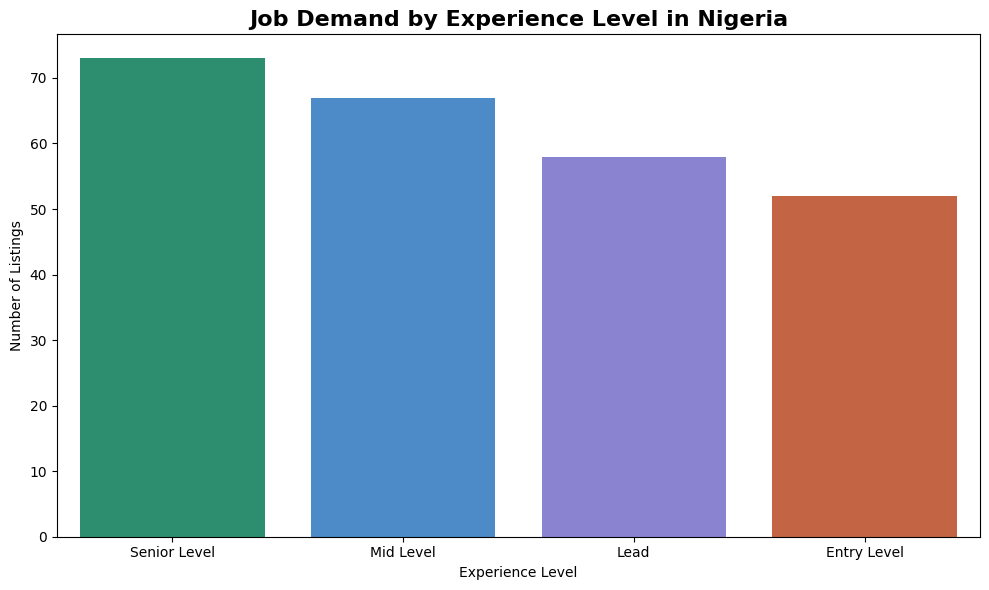

  Experience Level  Count
0     Senior Level     73
1        Mid Level     67
2             Lead     58
3      Entry Level     52


In [9]:
# ---- Analysis 6: Experience level demand ----
exp_counts = df['experience'].value_counts().reset_index()
exp_counts.columns = ['Experience Level', 'Count']

plt.figure(figsize=(10, 6))
colors = ['#1D9E75', '#378ADD', '#7F77DD', '#D85A30']
sns.barplot(data=exp_counts, x='Experience Level', y='Count', palette=colors)
plt.title('Job Demand by Experience Level in Nigeria', fontsize=16, fontweight='bold')
plt.xlabel('Experience Level')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.savefig('chart6_experience_levels.png', dpi=150)
plt.show()

print(exp_counts)

In [10]:
# ---- Final Summary: Key Insights ----
print("=" * 55)
print("   NIGERIAN JOB MARKET ANALYSIS — KEY INSIGHTS")
print("=" * 55)

print(f"\n📊 Dataset: {len(df)} job listings analyzed")

top_skill = all_skills and Counter(all_skills).most_common(1)[0][0]
print(f"\n🔥 Most in-demand skill:     {top_skill}")

top_role = avg_salary.iloc[0]['Job Title']
top_pay  = avg_salary.iloc[0]['Average Salary (NGN)']
print(f"💰 Highest paying role:      {top_role}")
print(f"   Average salary:          ₦{top_pay:,.0f}/month")

top_location = location_counts.iloc[0]['Location']
remote_pct   = location_counts[location_counts['Location'] == 'Remote']['Job Count'].values
remote_pct   = round(remote_pct[0] / len(df) * 100, 1) if len(remote_pct) else 0
print(f"\n📍 Top location:             {top_location}")
print(f"   Remote job share:        {remote_pct}%")

top_company = top_companies.iloc[0]['Company']
print(f"\n🏢 Most active employer:     {top_company}")

top_exp = exp_counts.iloc[0]['Experience Level']
print(f"\n🎯 Most sought experience:   {top_exp}")

top_type = job_type_counts.iloc[0]['Job Type']
print(f"📋 Most common job type:     {top_type}")

print("\n" + "=" * 55)
print("  Analysis by: Nigerian Job Market Analyzer v1.0")
print("=" * 55)

   NIGERIAN JOB MARKET ANALYSIS — KEY INSIGHTS

📊 Dataset: 250 job listings analyzed

🔥 Most in-demand skill:     SQL
💰 Highest paying role:      Machine Learning Engineer
   Average salary:          ₦594,500/month

📍 Top location:             Remote
   Remote job share:        29.6%

🏢 Most active employer:     Paystack

🎯 Most sought experience:   Senior Level
📋 Most common job type:     Contract

  Analysis by: Nigerian Job Market Analyzer v1.0
